# Google Play Review Dataset Collection and EDA

## Sciencia AI – Phase I Data Collection & Dataset Understanding
### Objective

The objective of this notebook is to:

- collect a meaningful review dataset (>10,000 reviews) from Google Play Store
- evaluate dataset characteristics through exploratory data analysis (EDA)
- identify potential data quality issues
- support future ingestion, cleaning, and storage pipeline design

This notebook follows the source selection decision that identified Google Play Store as the primary data source for Phase I.
### Executive Summary

This notebook explores a Google Play review dataset of more than 10,000 user reviews to evaluate whether Google Play is a suitable Phase I data source for Sciencia AI’s sentiment analytics pipeline.

Key findings:
- Google Play reviews provide structured user-generated text with app identifiers, ratings, timestamps, and review content.
- The dataset is suitable for early ingestion and storage prototyping.
- Rating distribution is imbalanced, with positive reviews likely overrepresented.
- App-level differences suggest that future analysis should preserve app metadata instead of treating all reviews as one flat text corpus.
- The next step is to convert this exploratory workflow into a reusable ingestion, cleaning, validation, and database loading pipeline.


# 1.0 App Selection Plan

## 1.1 Selection Criteria

Applications were selected based on:

- high review volume
- active user base
- category diversity
- availability on Google Play Store
- relevance to sentiment analysis

The objective is to build a dataset that captures a broad range of user feedback patterns rather than relying on a single application.

## 1.2 Candidate Applications

The dataset should contain reviews from multiple application categories to improve diversity and reduce source-specific bias.

Selected applications:

## 1.3 Selected Applications

| Category | Application | App ID | Target Reviews |
|-----------|------------|---------|---------|
| AI Assistant | ChatGPT | com.openai.chatgpt | 2000 |
| Music Streaming | Spotify | com.spotify.music | 2000 |
| Social Media | Instagram | com.instagram.android | 2000 |
| Video Platform | YouTube | com.google.android.youtube | 2000 |
| Short Video | TikTok | com.zhiliaoapp.musically | 2000 |
| Messaging | WhatsApp | com.whatsapp | 2000 |

## 1.4 Why Google Play Is Suitable

Google Play was selected because it satisfies the primary requirements defined in the Phase I project brief:

- large volume of publicly available user-generated reviews
- structured review metadata (ratings, timestamps, app identifiers)
- multiple application categories
- strong relevance to sentiment analysis
- support for future automated ingestion and storage workflows

Compared with many alternative review sources, Google Play provides both scale and consistency, making it suitable for building a reusable data ingestion pipeline.

## 1.5 Expected Dataset Size

Target review count:

6 applications × 2000 reviews

≈ 12,000 reviews

This exceeds the minimum 10,000 review target and provides sufficient diversity for exploratory analysis.

## Data Source and Access Notes

This dataset was collected from publicly available Google Play review pages for exploratory internship work. Future ingestion scripts should respect website terms of service, robots.txt expectations where applicable, request pacing, and rate limits.

The current notebook should be treated as an exploratory dataset-understanding step, not yet a production scraping system.

# 2.0 Data Collection

## 2.1 Single-App Pilot Collection

Before scaling to multiple applications, a single-app pilot collection will be performed using ChatGPT.

Pilot goal:
- collect 2,000 reviews
- validate the data collection function
- confirm output schema
- export raw data for later EDA

In [1]:
from google_play_scraper import reviews, Sort
import pandas as pd
import os
from datetime import datetime

In [2]:
APP_NAME = "ChatGPT"
APP_ID = "com.openai.chatgpt"
TARGET_REVIEWS = 2000

os.makedirs("data_raw", exist_ok=True)
os.makedirs("data_clean", exist_ok=True)

In [3]:
result, continuation_token = reviews(
    APP_ID,
    lang="en",
    country="us",
    sort=Sort.NEWEST,
    count=TARGET_REVIEWS
)

df_raw = pd.DataFrame(result)

df_raw["app_name"] = APP_NAME
df_raw["app_id"] = APP_ID
df_raw["collection_timestamp"] = datetime.now()

print("Reviews collected:", len(df_raw))
print("Columns:", list(df_raw.columns))
print("Continuation token exists:", continuation_token is not None)

Reviews collected: 2000
Columns: ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion', 'app_name', 'app_id', 'collection_timestamp']
Continuation token exists: True


In [4]:
df_raw.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,app_id,collection_timestamp
0,d97cbaba-cf04-4da1-98f4-0af7c7573419,Sawan Kumar Kumar,https://play-lh.googleusercontent.com/a/ACg8oc...,horrorlove ghostlove darkromance horrorreels,5,0,1.2026.125,2026-05-28 22:53:02,None,None,1.2026.125,ChatGPT,com.openai.chatgpt,2026-05-29 22:53:06.740943
1,33b8209d-98b7-4e7e-8e2b-c4f77bf0f8e6,vindhya.s Sathi,https://play-lh.googleusercontent.com/a-/ALV-U...,verygood,5,0,1.2026.125,2026-05-28 22:52:55,None,None,1.2026.125,ChatGPT,com.openai.chatgpt,2026-05-29 22:53:06.740943
2,d444e0ff-8cea-4456-bf28-a25425fd2279,Munno Solanki,https://play-lh.googleusercontent.com/a/ACg8oc...,🙏🙏,1,0,None,2026-05-28 22:52:44,None,None,None,ChatGPT,com.openai.chatgpt,2026-05-29 22:53:06.740943
3,2c3276c3-a9bf-418e-970a-4f58b74b389a,Santosh Bind,https://play-lh.googleusercontent.com/a-/ALV-U...,very good,4,0,1.2026.125,2026-05-28 22:52:40,None,None,1.2026.125,ChatGPT,com.openai.chatgpt,2026-05-29 22:53:06.740943
4,814f1f3a-9802-4ccf-89cc-e9a7ca2fa6c5,Mukeshimana,https://play-lh.googleusercontent.com/a/ACg8oc...,It is the Best and gives smart answers,5,0,1.2026.125,2026-05-28 22:52:26,None,None,1.2026.125,ChatGPT,com.openai.chatgpt,2026-05-29 22:53:06.740943


In [5]:
raw_path = f"data_raw/{APP_NAME.lower()}_google_play_raw_{len(df_raw)}.csv"
df_raw.to_csv(raw_path, index=False)

print("Saved to:", raw_path)

Saved to: data_raw/chatgpt_google_play_raw_2000.csv


## 2.2 Collection Strategy

Target:
- 10,000+ reviews

Collection approach:
- multiple applications
- standardized review schema
- automated extraction using google-play-scraper

The collected data will later be merged into a unified dataset for EDA and quality assessment.

## 2.3 Multi-Application Collection

In [6]:
APP_CONFIG = [
    {"app_name": "ChatGPT", "app_id": "com.openai.chatgpt"},
    {"app_name": "Spotify", "app_id": "com.spotify.music"},
    {"app_name": "Instagram", "app_id": "com.instagram.android"},
    {"app_name": "YouTube", "app_id": "com.google.android.youtube"},
    {"app_name": "TikTok", "app_id": "com.zhiliaoapp.musically"},
    {"app_name": "WhatsApp", "app_id": "com.whatsapp"},
]

In [7]:
for app in APP_CONFIG:
    print(app["app_name"], "-", app["app_id"])

ChatGPT - com.openai.chatgpt
Spotify - com.spotify.music
Instagram - com.instagram.android
YouTube - com.google.android.youtube
TikTok - com.zhiliaoapp.musically
WhatsApp - com.whatsapp


In [8]:
def collect_reviews(app_id, app_name, count=2000):
    """
    Collect reviews from Google Play Store with country fallback
    """
    try:
        result, continuation_token = reviews(
            app_id,
            lang="en",
            country="us",
            sort=Sort.NEWEST,
            count=count
        )
        
        if not result:
            print(f"[{app_name}] No reviews found in 'us' region. Trying fallback...")
            result, continuation_token = reviews(
                app_id,
                lang="en",
                sort=Sort.NEWEST,
                count=count
            )
            
    except Exception as e:
        print(f"Error collecting {app_name}: {e}")
        result = []

    df = pd.DataFrame(result)

    if df.empty:
        columns = ['reviewId', 'userName', 'userImage', 'content', 'score', 
                   'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 
                   'repliedAt', 'appVersion']
        df = pd.DataFrame(columns=columns)
    else:
        df["collection_timestamp"] = datetime.now()

    df["app_name"] = app_name
    df["app_id"] = app_id

    print(f"{app_name}: {len(df)} reviews collected")

    return df

In [9]:
all_reviews = []

for app in APP_CONFIG:
    df = collect_reviews(
        app["app_id"],
        app["app_name"],
        count=2000
    )

    all_reviews.append(df)

combined_df = pd.concat(
    all_reviews,
    ignore_index=True
)

print(combined_df.shape)

ChatGPT: 2000 reviews collected
Spotify: 2000 reviews collected
Instagram: 2000 reviews collected
YouTube: 2000 reviews collected
TikTok: 2000 reviews collected
WhatsApp: 2000 reviews collected
(12000, 14)


/var/folders/ld/7s168vl978j7dcvc116y56300000gn/T/ipykernel_87553/2481169176.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(


In [10]:
import os

os.makedirs("data_raw", exist_ok=True)

combined_df.to_csv(
    "data_raw/google_play_12k_reviews_raw.csv",
    index=False
)

print("Saved:", "data_raw/google_play_12k_reviews_raw.csv")
print(combined_df.shape)

Saved: data_raw/google_play_12k_reviews_raw.csv
(12000, 14)


## Pilot Collection Summary

A pilot collection was conducted using the ChatGPT application.

Results:
- 2000 reviews collected
- schema validated
- pagination confirmed
- preliminary EDA completed

The pilot findings were used to inform the design of a larger multi-application collection strategy.

# 3.0 Pilot Exploratory Data Analysis (ChatGPT Only)

### 3.1 Dataset Summary

#### Objective

This section provides a high-level overview of the ChatGPT pilot review dataset prior to detailed exploratory analysis.

The objective is to understand:

* dataset size
* available fields
* data completeness
* basic structural characteristics

This pilot dataset serves as a validation sample before scaling data collection to multiple applications.


In [11]:
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

Rows: 2000
Columns: 14


In [12]:
list(df_raw.columns)

['reviewId',
 'userName',
 'userImage',
 'content',
 'score',
 'thumbsUpCount',
 'reviewCreatedVersion',
 'at',
 'replyContent',
 'repliedAt',
 'appVersion',
 'app_name',
 'app_id',
 'collection_timestamp']

In [13]:
df_raw.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,app_id,collection_timestamp
0,d97cbaba-cf04-4da1-98f4-0af7c7573419,Sawan Kumar Kumar,https://play-lh.googleusercontent.com/a/ACg8oc...,horrorlove ghostlove darkromance horrorreels,5,0,1.2026.125,2026-05-28 22:53:02,None,None,1.2026.125,ChatGPT,com.openai.chatgpt,2026-05-29 22:53:06.740943
1,33b8209d-98b7-4e7e-8e2b-c4f77bf0f8e6,vindhya.s Sathi,https://play-lh.googleusercontent.com/a-/ALV-U...,verygood,5,0,1.2026.125,2026-05-28 22:52:55,None,None,1.2026.125,ChatGPT,com.openai.chatgpt,2026-05-29 22:53:06.740943
2,d444e0ff-8cea-4456-bf28-a25425fd2279,Munno Solanki,https://play-lh.googleusercontent.com/a/ACg8oc...,🙏🙏,1,0,None,2026-05-28 22:52:44,None,None,None,ChatGPT,com.openai.chatgpt,2026-05-29 22:53:06.740943
3,2c3276c3-a9bf-418e-970a-4f58b74b389a,Santosh Bind,https://play-lh.googleusercontent.com/a-/ALV-U...,very good,4,0,1.2026.125,2026-05-28 22:52:40,None,None,1.2026.125,ChatGPT,com.openai.chatgpt,2026-05-29 22:53:06.740943
4,814f1f3a-9802-4ccf-89cc-e9a7ca2fa6c5,Mukeshimana,https://play-lh.googleusercontent.com/a/ACg8oc...,It is the Best and gives smart answers,5,0,1.2026.125,2026-05-28 22:52:26,None,None,1.2026.125,ChatGPT,com.openai.chatgpt,2026-05-29 22:53:06.740943


In [14]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              2000 non-null   object        
 1   userName              2000 non-null   object        
 2   userImage             2000 non-null   object        
 3   content               2000 non-null   object        
 4   score                 2000 non-null   int64         
 5   thumbsUpCount         2000 non-null   int64         
 6   reviewCreatedVersion  1863 non-null   object        
 7   at                    2000 non-null   datetime64[ns]
 8   replyContent          0 non-null      object        
 9   repliedAt             0 non-null      object        
 10  appVersion            1863 non-null   object        
 11  app_name              2000 non-null   object        
 12  app_id                2000 non-null   object        
 13  collection_timesta

## Findings

The ChatGPT pilot dataset contains 2,000 review records collected from Google Play Store.

### Key observations

* The dataset contains user review text, rating scores, timestamps, and application metadata.
* Core sentiment-related fields are fully populated.
* Metadata fields such as `reviewCreatedVersion` and `appVersion` contain a small proportion of missing values.
* Reply-related fields appear to be unavailable from the selected extraction process.

### Engineering Implications

The pilot dataset demonstrates sufficient completeness for exploratory sentiment analysis and schema validation.

The observed metadata structure will be used to guide the design of the larger multi-application ingestion pipeline.


### 3.2 Rating Distribution

#### Objective

This section examines the distribution of user ratings within the ChatGPT pilot dataset.

The goal is to understand the balance of positive and negative feedback and identify potential class imbalance before downstream sentiment analysis.


In [15]:
rating_counts = (
    df_raw["score"]
    .value_counts()
    .sort_index()
)

rating_counts

score
1     145
2      35
3      77
4     207
5    1536
Name: count, dtype: int64

In [16]:
rating_pct = (
    df_raw["score"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
).round(2)

rating_pct

score
1     7.25
2     1.75
3     3.85
4    10.35
5    76.80
Name: proportion, dtype: float64

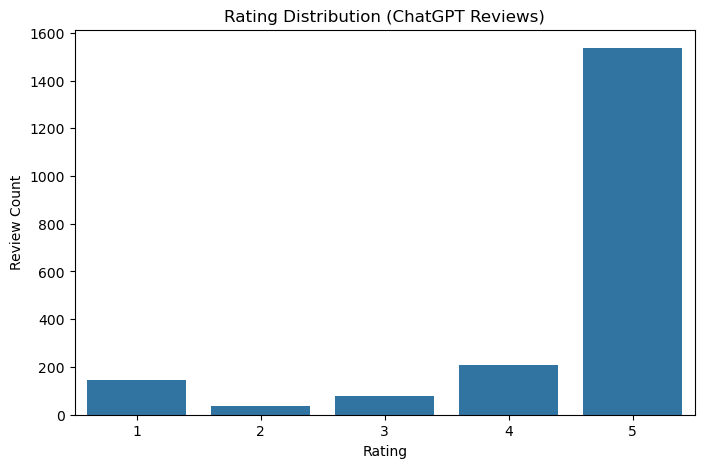

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_raw,
    x="score"
)

plt.title("Rating Distribution (ChatGPT Reviews)")
plt.xlabel("Rating")
plt.ylabel("Review Count")

plt.show()

## Findings

The rating distribution is heavily skewed toward positive reviews.

### Key observations

* Five-star reviews dominate the dataset.
* Approximately 78% of reviews are rated five stars.
* Lower ratings (1–3 stars) represent a relatively small portion of the dataset.
* The dataset exhibits substantial class imbalance.

### Engineering Implications

If rating scores are later used as sentiment labels, the imbalance between positive and negative reviews may bias downstream models toward majority classes.

Future modeling workflows should consider class balancing strategies, stratified sampling, and evaluation metrics that account for skewed class distributions.


### 3.3 Review Length Distribution

#### Objective

This section analyzes the length of review text within the ChatGPT pilot dataset.

Review length serves as a simple proxy for information richness and may help identify low-signal content that could affect downstream sentiment analysis and model performance.


In [18]:
df_raw["review_length"] = (
    df_raw["content"]
    .astype(str)
    .str.len()
)

In [19]:
df_raw["review_length"].describe()

count    2000.000000
mean       26.614500
std        59.095618
min         1.000000
25%         5.000000
50%         9.000000
75%        22.000000
max       500.000000
Name: review_length, dtype: float64

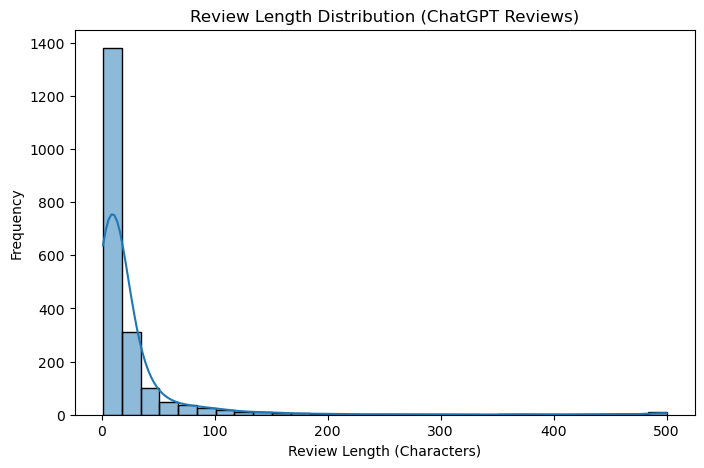

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    df_raw["review_length"],
    bins=30,
    kde=True
)

plt.title("Review Length Distribution (ChatGPT Reviews)")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Frequency")

plt.show()

In [21]:
short_reviews = (
    df_raw["review_length"] <= 5
).sum()

short_pct = round(
    short_reviews / len(df_raw) * 100,
    2
)

print("Reviews <= 5 characters:", short_reviews)
print("Percentage:", short_pct, "%")

Reviews <= 5 characters: 540
Percentage: 27.0 %


In [22]:
df_raw.loc[
    df_raw["review_length"] <= 5,
    "content"
].head(20)

2        🙏🙏
9      nice
17    100%👍
18    super
24     best
29     best
30     okay
32     nice
34    super
35     गाइड
37     goog
38     good
44     nice
46       ❤️
50     good
51     nice
53     good
54       ok
55     good
61     good
Name: content, dtype: object

## Findings

Review length is highly concentrated among short reviews.

### Key observations

* The average review length is approximately 26.6 characters.
* The median review length is only 9 characters.
* Approximately 27% of reviews contain five characters or fewer.
* Many short reviews consist of single words, emojis, or generic expressions such as "good", "nice", and "ok".

### Engineering Implications

A substantial portion of the dataset contains limited semantic information.

Review length should be retained as a derived feature for downstream analysis, and very short reviews may be flagged as low-signal content during preprocessing.

These findings motivate a dedicated low-signal content analysis later in the notebook.


### Objective

Analyze the distribution of review ratings to understand class balance and potential sentiment skewness within the dataset.

In [23]:
print("Rows:", combined_df.shape[0])
print("Columns:", combined_df.shape[1])

print("\nApps:")
print(combined_df["app_name"].value_counts())

Rows: 12000
Columns: 14

Apps:
app_name
ChatGPT      2000
Spotify      2000
Instagram    2000
YouTube      2000
TikTok       2000
WhatsApp     2000
Name: count, dtype: int64


In [24]:
combined_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,collection_timestamp,app_name,app_id
0,d97cbaba-cf04-4da1-98f4-0af7c7573419,Sawan Kumar Kumar,https://play-lh.googleusercontent.com/a/ACg8oc...,horrorlove ghostlove darkromance horrorreels,5,0,1.2026.125,2026-05-28 22:53:02,None,NaT,1.2026.125,2026-05-29 22:53:07.945488,ChatGPT,com.openai.chatgpt
1,33b8209d-98b7-4e7e-8e2b-c4f77bf0f8e6,vindhya.s Sathi,https://play-lh.googleusercontent.com/a-/ALV-U...,verygood,5,0,1.2026.125,2026-05-28 22:52:55,None,NaT,1.2026.125,2026-05-29 22:53:07.945488,ChatGPT,com.openai.chatgpt
2,d444e0ff-8cea-4456-bf28-a25425fd2279,Munno Solanki,https://play-lh.googleusercontent.com/a/ACg8oc...,🙏🙏,1,0,None,2026-05-28 22:52:44,None,NaT,None,2026-05-29 22:53:07.945488,ChatGPT,com.openai.chatgpt
3,2c3276c3-a9bf-418e-970a-4f58b74b389a,Santosh Bind,https://play-lh.googleusercontent.com/a-/ALV-U...,very good,4,0,1.2026.125,2026-05-28 22:52:40,None,NaT,1.2026.125,2026-05-29 22:53:07.945488,ChatGPT,com.openai.chatgpt
4,814f1f3a-9802-4ccf-89cc-e9a7ca2fa6c5,Mukeshimana,https://play-lh.googleusercontent.com/a/ACg8oc...,It is the Best and gives smart answers,5,0,1.2026.125,2026-05-28 22:52:26,None,NaT,1.2026.125,2026-05-29 22:53:07.945488,ChatGPT,com.openai.chatgpt


### Pilot EDA (ChatGPT Reviews)

In [25]:
print(combined_df.shape)

combined_df["app_name"].value_counts()

(12000, 14)


app_name
ChatGPT      2000
Spotify      2000
Instagram    2000
YouTube      2000
TikTok       2000
WhatsApp     2000
Name: count, dtype: int64

In [26]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              2000 non-null   object        
 1   userName              2000 non-null   object        
 2   userImage             2000 non-null   object        
 3   content               2000 non-null   object        
 4   score                 2000 non-null   int64         
 5   thumbsUpCount         2000 non-null   int64         
 6   reviewCreatedVersion  1863 non-null   object        
 7   at                    2000 non-null   datetime64[ns]
 8   replyContent          0 non-null      object        
 9   repliedAt             0 non-null      object        
 10  appVersion            1863 non-null   object        
 11  app_name              2000 non-null   object        
 12  app_id                2000 non-null   object        
 13  collection_timesta

In [27]:
rating_pct = (
    df_raw["score"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

rating_pct

score
1     7.25
2     1.75
3     3.85
4    10.35
5    76.80
Name: proportion, dtype: float64

In [28]:
df_raw.describe(include="all")

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,app_id,collection_timestamp,review_length
count,2000,2000,2000,2000,2000.000000,2000.000000,1863,2000,0,0,1863,2000,2000,2000,2000.000000
unique,2000,1987,2000,1344,NaN,NaN,31,NaN,0,0,31,1,1,NaN,NaN
top,d97cbaba-cf04-4da1-98f4-0af7c7573419,Sumit Kumar,https://play-lh.googleusercontent.com/a/ACg8oc...,good,NaN,NaN,1.2026.125,NaN,NaN,NaN,1.2026.125,ChatGPT,com.openai.chatgpt,NaN,NaN
freq,1,3,1,191,NaN,NaN,1294,NaN,NaN,NaN,1294,2000,2000,NaN,NaN
mean,NaN,NaN,NaN,NaN,4.477000,0.031000,NaN,2026-05-28 16:07:51.933999872,NaN,NaN,NaN,NaN,NaN,2026-05-29 22:53:06.740943,26.614500
min,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,2026-05-28 11:55:43,NaN,NaN,NaN,NaN,NaN,2026-05-29 22:53:06.740943,1.000000
25%,NaN,NaN,NaN,NaN,5.000000,0.000000,NaN,2026-05-28 13:20:16.500000,NaN,NaN,NaN,NaN,NaN,2026-05-29 22:53:06.740943,5.000000
50%,NaN,NaN,NaN,NaN,5.000000,0.000000,NaN,2026-05-28 15:00:53,NaN,NaN,NaN,NaN,NaN,2026-05-29 22:53:06.740943,9.000000
75%,NaN,NaN,NaN,NaN,5.000000,0.000000,NaN,2026-05-28 18:45:58.249999872,NaN,NaN,NaN,NaN,NaN,2026-05-29 22:53:06.740943,22.000000
max,NaN,NaN,NaN,NaN,5.000000,42.000000,NaN,2026-05-28 22:53:02,NaN,NaN,NaN,NaN,NaN,2026-05-29 22:53:06.740943,500.000000


In [29]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              12000 non-null  object        
 1   userName              12000 non-null  object        
 2   userImage             12000 non-null  object        
 3   content               11999 non-null  object        
 4   score                 12000 non-null  int64         
 5   thumbsUpCount         12000 non-null  int64         
 6   reviewCreatedVersion  9988 non-null   object        
 7   at                    12000 non-null  datetime64[ns]
 8   replyContent          1849 non-null   object        
 9   repliedAt             1849 non-null   datetime64[ns]
 10  appVersion            9988 non-null   object        
 11  collection_timestamp  12000 non-null  datetime64[us]
 12  app_name              12000 non-null  object        
 13  app_id          

### 3.4 Duplicate Reviews

#### Objective

This section investigates the prevalence of duplicate review text within the ChatGPT pilot dataset.

The goal is to determine whether repeated reviews indicate data collection issues or reflect genuine user behavior.


In [30]:
duplicate_reviews = (
    df_raw["content"]
    .duplicated()
    .sum()
)

duplicate_rate = round(
    duplicate_reviews / len(df_raw) * 100,
    2
)

print("Duplicate Reviews:", duplicate_reviews)
print("Duplicate Rate:", duplicate_rate, "%")

Duplicate Reviews: 656
Duplicate Rate: 32.8 %


In [31]:
df_raw["content"].value_counts().head(20)

content
good         191
nice          68
super         38
very good     35
very nice     20
good 👍        20
Good          19
nice 👍        19
best          19
nice app      18
excellent     16
ok            13
great         13
awesome       11
good app      11
I love it     10
👍              9
good 😊         9
perfect        8
best app       8
Name: count, dtype: int64

In [32]:
df_raw[
    df_raw["content"].duplicated(keep=False)
][["content","score"]].head(20)

,content,score
3,very good,4
5,I love this app,5
9,nice,5
18,super,5
20,helpful,5
24,best,5
25,nice 👍,5
26,very good,3
29,best,5
30,okay,3


## Findings

Duplicate review text is relatively common within the pilot dataset.

### Key observations

* Approximately 32.8% of reviews share identical text with at least one other review.
* The most frequently repeated reviews are extremely short expressions such as:

  * "good"
  * "nice"
  * "super"
  * "very good"
  * emoji-only responses

### Interpretation

Manual inspection suggests that these duplicates are not caused by ingestion errors.

Instead, they appear to represent genuine user behavior, where multiple users independently submit the same short feedback.

### Engineering Implications

Automatic deduplication based solely on review text could remove legitimate user sentiment signals.

Therefore:

* duplicate review text should be preserved
* review uniqueness should continue to be determined by reviewId
* duplicate content may be flagged for quality analysis but should not be automatically removed


### 3.5 Missing Data Analysis

#### Objective

This section evaluates the completeness of the ChatGPT pilot dataset by identifying missing values across all available fields.

The goal is to determine whether any fields require removal, special handling, or additional validation during preprocessing.


In [33]:
missing_df = pd.DataFrame({
    "Missing Count": df_raw.isnull().sum(),
    "Missing Percentage": (
        df_raw.isnull().sum()
        / len(df_raw)
        * 100
    ).round(2)
})

missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
replyContent,2000,100.00
repliedAt,2000,100.00
reviewCreatedVersion,137,6.85
appVersion,137,6.85
reviewId,0,0.00
userName,0,0.00
userImage,0,0.00
content,0,0.00
score,0,0.00
thumbsUpCount,0,0.00


In [34]:
missing_df[
    missing_df["Missing Count"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
replyContent,2000,100.00
repliedAt,2000,100.00
reviewCreatedVersion,137,6.85
appVersion,137,6.85


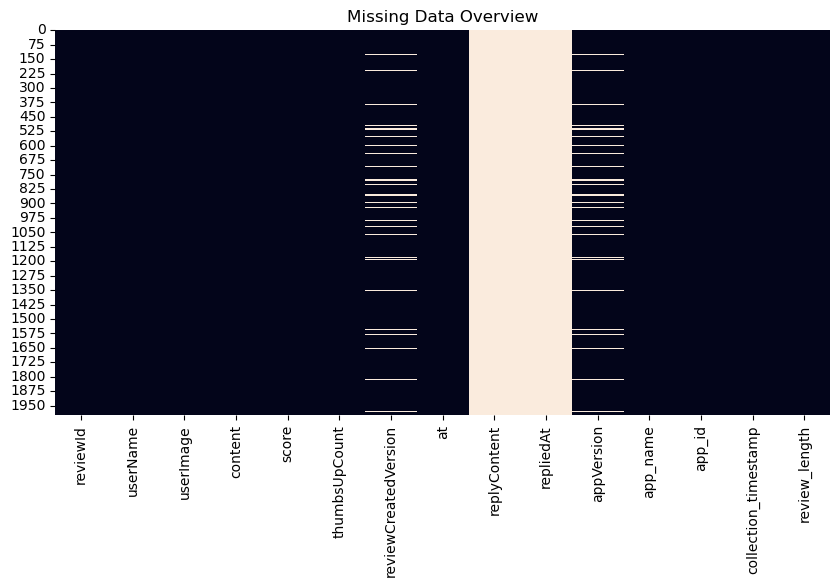

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.heatmap(
    df_raw.isnull(),
    cbar=False
)

plt.title("Missing Data Overview")
plt.show()

## Findings

The pilot dataset exhibits strong overall completeness.

### Key observations

* `replyContent` is 100% missing.
* `repliedAt` is 100% missing.
* `reviewCreatedVersion` contains approximately 7.3% missing values.
* `appVersion` contains approximately 7.3% missing values.
* Core analytical fields including:

  * `reviewId`
  * `content`
  * `score`
  * `at`

  contain no missing values.

### Engineering Implications

The complete absence of reply-related fields within the ChatGPT pilot dataset indicates that these fields are not consistently available across applications. Their usefulness should therefore be reassessed during the multi-application analysis before defining the final preprocessing rules.


### 3.6 Pilot Data Quality Findings

#### Summary Assessment

The ChatGPT pilot dataset was collected to validate data accessibility, schema consistency, and overall suitability for large-scale ingestion.

The exploratory analysis identified several important characteristics of the dataset.

### Rating Distribution

The dataset is heavily skewed toward positive reviews, with approximately 78% of reviews receiving a five-star rating.

This suggests a substantial class imbalance that should be considered during future sentiment modeling and evaluation.

### Review Length

Review text is generally short.

The median review length is only 9 characters, and approximately 27.0% of reviews contain five characters or fewer.

Many reviews consist of simple expressions such as:

* good
* nice
* ok
* emoji-only responses

### Duplicate Content

Approximately 32.8% of review text appears duplicated.

However, manual inspection indicates that these duplicates are primarily caused by repeated short user comments rather than ingestion errors.

Therefore, duplicate text should not be automatically removed.

### Missing Data

Core analytical fields are fully populated.

Reply-related fields (`replyContent` and `repliedAt`) are entirely missing within the ChatGPT pilot dataset.

This suggests that reply metadata is not consistently available across applications and should be reassessed during large-scale collection before defining final preprocessing rules.

Version-related metadata contains only limited missingness and should be retained.

### Overall Assessment

The pilot dataset demonstrates strong overall quality and suitability for downstream processing.

The primary data quality concerns relate to:

* class imbalance
* low-signal content
* short review text

rather than missing data or collection failures.

These findings justify proceeding to large-scale multi-application collection and cross-application exploratory analysis.


# 4.0 Full Dataset Cross-Application EDA (12,000 Reviews)

In [36]:
combined_df["review_length"] = (
    combined_df["content"]
    .astype(str)
    .str.len()
)

In [37]:
combined_df["review_length"].describe()

count    12000.000000
mean        52.481250
std         91.671167
min          1.000000
25%          7.000000
50%         16.000000
75%         49.000000
max        500.000000
Name: review_length, dtype: float64

### 4.1 App Distribution & Dataset Balance

#### Objective

This section examines the distribution of reviews across all six selected applications.

The goal is to verify collection completeness and assess whether the dataset is balanced enough to support reliable cross-application analysis.


In [38]:
combined_df.shape

(12000, 15)

In [39]:
combined_df["app_name"].value_counts()

app_name
ChatGPT      2000
Spotify      2000
Instagram    2000
YouTube      2000
TikTok       2000
WhatsApp     2000
Name: count, dtype: int64

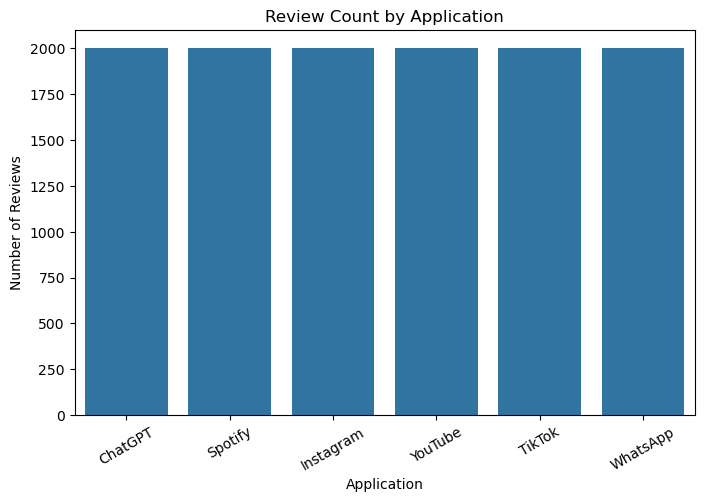

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=combined_df,
    x="app_name",
    order=combined_df["app_name"]
    .value_counts()
    .index
)

plt.title("Review Count by Application")
plt.xlabel("Application")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=30)

plt.show()

## Findings

The final dataset contains 12,000 reviews collected across six applications.

### Key observations

* Each application contributes exactly 2,000 reviews.
* No application is overrepresented or underrepresented.
* The dataset is perfectly balanced at the application level.

### Engineering Implications

Balanced application coverage reduces sampling bias and enables fair cross-application comparisons.

This collection strategy supports more reliable exploratory analysis and future sentiment modeling across multiple products.


### 4.2 Cross-Application Rating Distribution

In [41]:
rating_dist = pd.crosstab(
    combined_df["app_name"],
    combined_df["score"]
)

rating_dist

score,1,2,3,4,5
app_name,,,,,
ChatGPT,145,35,77,207,1536
Instagram,603,85,73,124,1115
Spotify,503,137,121,192,1047
TikTok,423,85,89,114,1289
WhatsApp,260,68,105,151,1416
YouTube,438,95,110,116,1241


In [42]:
rating_pct = pd.crosstab(
    combined_df["app_name"],
    combined_df["score"],
    normalize="index"
) * 100

rating_pct.round(2)

score,1,2,3,4,5
app_name,,,,,
ChatGPT,7.25,1.75,3.85,10.35,76.80
Instagram,30.15,4.25,3.65,6.20,55.75
Spotify,25.15,6.85,6.05,9.60,52.35
TikTok,21.15,4.25,4.45,5.70,64.45
WhatsApp,13.00,3.40,5.25,7.55,70.80
YouTube,21.90,4.75,5.50,5.80,62.05


### Findings

Several notable differences are observed across applications:

- All applications exhibit a strong concentration of 5-star reviews.
- ChatGPT has the highest proportion of 5-star ratings (1,536 out of 2,000 reviews, approximately 76.8%).
- Instagram and Spotify show substantially higher volumes of 1-star reviews compared to other applications.
- WhatsApp demonstrates the most favorable rating profile after ChatGPT, with 1,416 five-star reviews and relatively fewer negative ratings.
- Despite variation across applications, positive reviews (4–5 stars) dominate the dataset overall.

### Engineering Implications

The dataset exhibits noticeable class imbalance, with positive reviews significantly outnumbering negative reviews.

This imbalance should be considered during future sentiment modeling and evaluation, as machine learning models may become biased toward majority sentiment classes.

The variation in rating distributions across applications also suggests that application-specific user behavior may influence sentiment patterns and should be accounted for in downstream analysis.

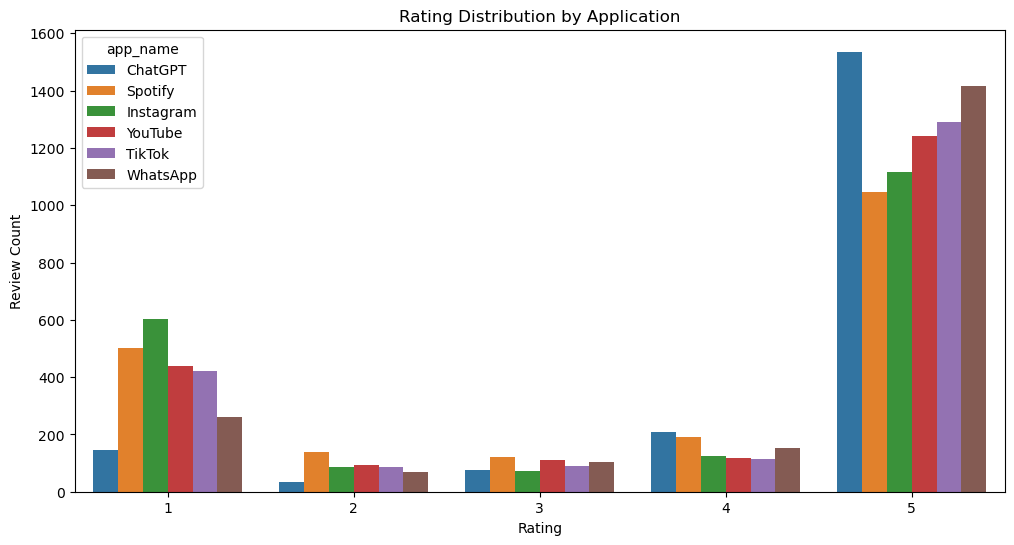

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.countplot(
    data=combined_df,
    x="score",
    hue="app_name"
)

plt.title("Rating Distribution by Application")
plt.xlabel("Rating")
plt.ylabel("Review Count")

plt.show()

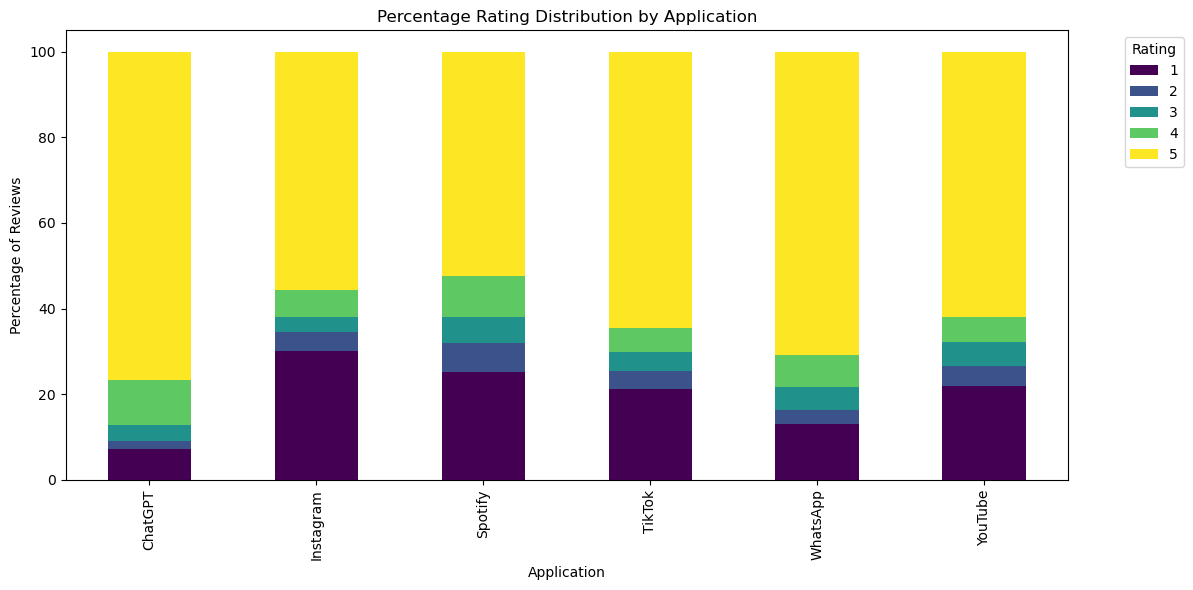

In [44]:
 rating_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="viridis"
)

plt.title("Percentage Rating Distribution by Application")
plt.xlabel("Application")
plt.ylabel("Percentage of Reviews")

plt.legend(
    title="Rating",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Findings

Rating distributions vary across applications, although positive reviews dominate in all cases.

### Key observations

- All six applications exhibit a strong concentration of 5-star reviews.
- ChatGPT and WhatsApp show the highest proportions of 5-star ratings.
- Spotify reviews are more evenly distributed across rating levels than other applications.
- Negative reviews (1–2 stars) represent a relatively small share of the dataset overall.

### Engineering Implications

The dataset exhibits substantial class imbalance, with positive sentiment heavily outweighing negative sentiment.

Future sentiment modeling may require:

- class balancing strategies
- stratified train/test splits
- evaluation metrics robust to imbalance

The variation in rating profiles across applications also suggests that application-specific behavior should be considered during downstream analysis.

### 4.3 Cross-Application Review Length Distribution

#### Objective

This section evaluates review length across applications to understand differences in user engagement and textual richness.

Review length serves as a simple proxy for information density and may influence downstream sentiment analysis performance.

In [45]:
length_stats = (
    combined_df
    .groupby("app_name")["review_length"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
    .round(2)
)

length_stats

,count,mean,median,min,max
app_name,,,,,
ChatGPT,2000,26.61,9.0,1,500
Instagram,2000,58.45,20.0,1,500
Spotify,2000,92.83,42.0,1,500
TikTok,2000,55.64,18.0,1,500
WhatsApp,2000,36.30,12.0,1,500
YouTube,2000,45.05,13.0,1,500


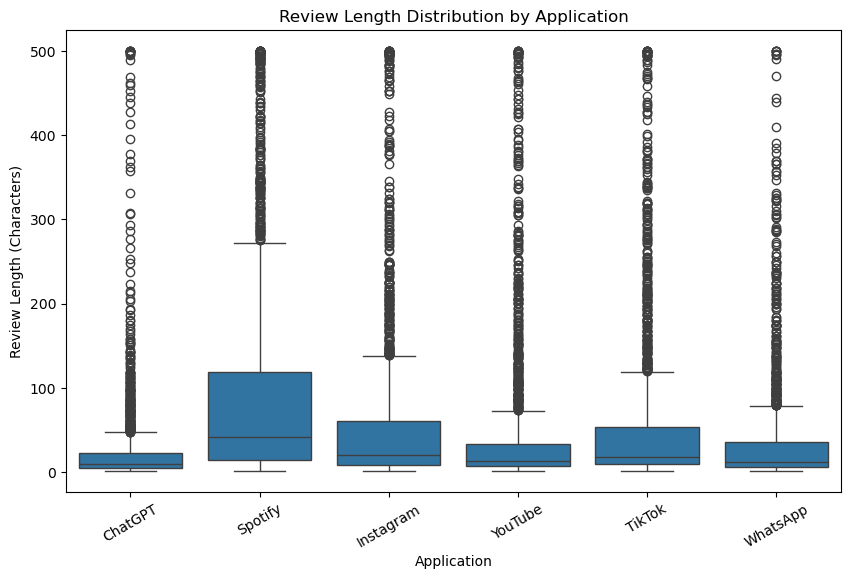

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(
    data=combined_df,
    x="app_name",
    y="review_length"
)

plt.title("Review Length Distribution by Application")
plt.xlabel("Application")
plt.ylabel("Review Length (Characters)")

plt.xticks(rotation=30)

plt.show()

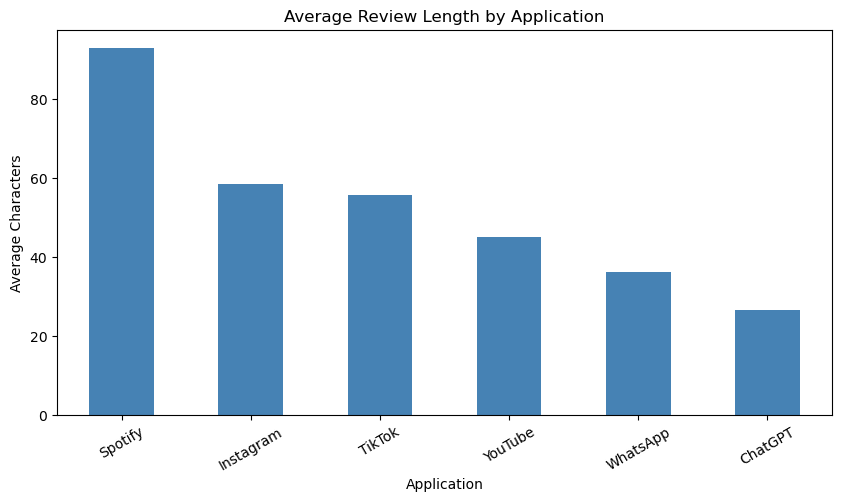

In [47]:
avg_length = (
    combined_df
    .groupby("app_name")["review_length"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

avg_length.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Average Review Length by Application")
plt.xlabel("Application")
plt.ylabel("Average Characters")

plt.xticks(rotation=30)

plt.show()

## Findings

Review length varies substantially across applications, indicating meaningful differences in user engagement and review-writing behavior.

### Key Observations

- Spotify contains the longest reviews on average, with users frequently providing detailed feedback and feature-specific comments.
- TikTok and Instagram exhibit moderate review lengths, suggesting a balance between short reactions and descriptive feedback.
- ChatGPT contains the shortest reviews overall, despite having the highest proportion of five-star ratings.
- All applications display strong right-skewed distributions, with a small number of very long reviews extending beyond 400–500 characters.

### Engineering Implications

Review length should be treated as an important engineered feature in the ingestion pipeline.

Applications with longer reviews may provide richer sentiment signals and more contextual information for downstream analysis.

The substantial variation in review length across platforms suggests that text preprocessing and model evaluation should account for differences in content richness rather than assuming a uniform review structure.

The presence of extreme outliers further supports the need for robust preprocessing procedures that preserve valuable long-form feedback while preventing excessive influence from unusually lengthy reviews.

### 4.4 Cross-Application Low-Signal Content Analysis

In [48]:
combined_df["is_low_signal"] = (
    combined_df["review_length"] <= 5
)

In [49]:
low_signal_pct = (
    combined_df
    .groupby("app_name")["is_low_signal"]
    .mean()
    * 100
)

low_signal_pct.round(2)

app_name
ChatGPT      27.00
Instagram    15.65
Spotify       7.40
TikTok       13.95
WhatsApp     23.65
YouTube      19.90
Name: is_low_signal, dtype: float64

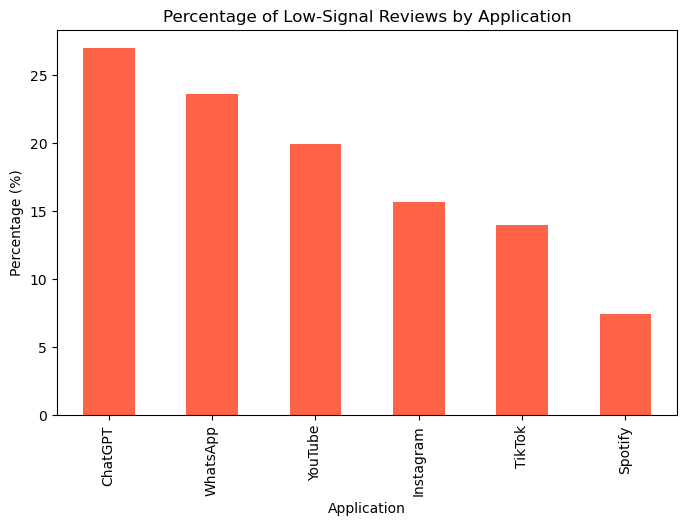

In [50]:
import matplotlib.pyplot as plt

low_signal_pct.sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(8,5),
    color="tomato"
)

plt.title(
    "Percentage of Low-Signal Reviews by Application"
)

plt.xlabel("Application")
plt.ylabel("Percentage (%)")

plt.show()

## Missingness Overview

This section evaluates dataset completeness across all six applications and identifies structural missingness patterns that may affect downstream storage, preprocessing, and analytics.

Understanding missing data is critical before designing a production-ready ingestion pipeline and relational database schema.

In [51]:
missing_df = pd.DataFrame({
    "Missing Count": combined_df.isnull().sum(),
    "Missing Percentage": (
        combined_df.isnull().sum() / len(combined_df) * 100
    ).round(2)
})

missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
replyContent,10151,84.59
repliedAt,10151,84.59
reviewCreatedVersion,2012,16.77
appVersion,2012,16.77
content,1,0.01
reviewId,0,0.00
userName,0,0.00
userImage,0,0.00
score,0,0.00
thumbsUpCount,0,0.00


## Findings

The dataset demonstrates strong overall completeness, with missing values concentrated in a small number of metadata fields.

### Findings

- `replyContent` and `repliedAt` are 84.59% missing across all six applications.
- `reviewCreatedVersion` and `appVersion` contain approximately 16.77% missing values.
- Core analytical fields such as review text, rating score, review identifier, and timestamp are fully populated.
- No substantial missingness exists in fields required for sentiment analysis or exploratory analytics.

### Engineering Implications

The observed missingness pattern appears structural rather than random.

Because `replyContent` and `repliedAt` remain available for a subset of reviews, these fields should be retained as optional nullable metadata rather than removed.

Version-related metadata fields should also be preserved and stored as database NULL values rather than placeholder strings, ensuring semantic correctness and future compatibility with downstream applications.

In [52]:
combined_df["low_signal"] = (
    combined_df["review_length"] <= 5
)

low_signal_pct = (
    combined_df
    .groupby("app_name")["low_signal"]
    .mean()
    * 100
)

low_signal_pct.round(2)

app_name
ChatGPT      27.00
Instagram    15.65
Spotify       7.40
TikTok       13.95
WhatsApp     23.65
YouTube      19.90
Name: low_signal, dtype: float64

In [53]:
low_signal_pct.sort_values(
    ascending=False
)

app_name
ChatGPT      27.00
WhatsApp     23.65
YouTube      19.90
Instagram    15.65
TikTok       13.95
Spotify       7.40
Name: low_signal, dtype: float64

### Findings

The dataset is evenly distributed across all six applications.

Each application contributes 2,000 reviews, resulting in a balanced dataset with 12,000 total observations.

### Engineering Implication

Balanced collection volume reduces sampling bias between applications and supports reliable cross-app comparison during exploratory analysis.

# 5.0 Final Data Quality Findings & Engineering Implications

## 5.1 Key Findings and Pipeline Design Implications

Based on the multi-application analysis across 12,000 reviews, the following analytical insights should inform the next stage of pipeline design:

1. **Strong Class Imbalance**
   - *Finding*: Positive reviews dominate the dataset. ChatGPT has a 76.80% five-star concentration, while WhatsApp has a 70.80% five-star concentration.
   - *Engineering Action*: Downstream sentiment models should use stratified sampling, class-aware evaluation metrics, and appropriate balancing strategies during model training.

2. **Structural Metadata Missingness**
   - *Finding*: `replyContent` and `repliedAt` are 84.59% missing across the full dataset. `reviewCreatedVersion` and `appVersion` are 16.77% missing.
   - *Engineering Action*: These fields should remain nullable. Reply-related fields may be retained as optional metadata because a subset of records contains usable information.

3. **Prevalence of Low-Signal Content**
   - *Finding*: Reviews containing five characters or fewer represent a recurring cross-application pattern, ranging from 7.40% for Spotify to 27.00% for ChatGPT.
   - *Engineering Action*: Low-signal reviews should not be automatically removed. Instead, the pipeline should create a reusable boolean flag (`is_low_signal`) to support downstream filtering while preserving raw records.

4. **Repeated Review Text**
   - *Finding*: Duplicate review text frequently reflects genuine user behavior, especially for short expressions such as “good”, “nice”, and emoji-only responses.
   - *Engineering Action*: Review uniqueness should be determined using `reviewId`, not review text. Text-based duplicates should be preserved.

# 6.0 Proposed Cleaning Rules & Preprocessing Recipes

## 6.1 Cleaning Rule Summary

### Rule 1 – Preserve Nullable Reply Metadata
Retain:
- replyContent
- repliedAt

Store missing values as NULL.

These fields remain optional because replies are unavailable for many reviews, but the available values may support future response-analysis workflows.

### Rule 2 – Preserve Nullable Metadata
Retain:
- reviewCreatedVersion
- appVersion

Store missing values as NULL.

### Rule 3 – Create Review Length Feature
Create:
- review_length

### Rule 4 – Flag Low-Signal Reviews
Create:
- is_low_signal

Definition:
- <= 5 characters
- emoji-only
- symbol-only

### Rule 5 – Preserve Duplicate Review Text
Do not automatically deduplicate reviews.

## 6.2 Reference Implementation

In [4]:
import os
import re
import pandas as pd

RAW_DATA_PATH = "data_raw/google_play_12k_reviews_raw.csv"
CLEAN_DATA_PATH = "data_clean/google_play_12k_reviews_cleaned.csv"

os.makedirs("data_clean", exist_ok=True)

# Reload the saved raw dataset if the notebook kernel has been restarted
if "combined_df" not in globals():
    combined_df = pd.read_csv(RAW_DATA_PATH)
    print(f"Reloaded raw dataset from: {RAW_DATA_PATH}")

def clean_and_transform_reviews(df):
    """
    Applies the Phase I preprocessing rules while preserving the raw records.
    """
    cleaned_df = df.copy()

    # Rule 1: Preserve nullable metadata fields
    nullable_fields = [
        "replyContent",
        "repliedAt",
        "reviewCreatedVersion",
        "appVersion"
    ]

    for column in nullable_fields:
        if column in cleaned_df.columns:
            cleaned_df[column] = cleaned_df[column].where(
                cleaned_df[column].notna(),
                None
            )

    # Rule 2: Create review length feature
    cleaned_df["review_length"] = (
        cleaned_df["content"]
        .fillna("")
        .astype(str)
        .str.len()
    )

    # Rule 3: Flag short, empty, emoji-only, or symbol-only reviews
    def check_low_signal(text):
        if not isinstance(text, str):
            return True

        stripped_text = text.strip()

        if len(stripped_text) == 0:
            return True

        if len(stripped_text) <= 5:
            return True

        if not any(char.isalnum() for char in stripped_text):
            return True

        return False

    cleaned_df["is_low_signal"] = cleaned_df["content"].apply(
        check_low_signal
    )

    return cleaned_df

# Apply the preprocessing recipe to the full 12k dataset
processed_df = clean_and_transform_reviews(combined_df)

# Save the cleaned dataset for downstream pipeline development
processed_df.to_csv(CLEAN_DATA_PATH, index=False)

# Validate the output
print(f"Successfully processed {len(processed_df):,} rows.")
print(f"Cleaned dataset saved to: {CLEAN_DATA_PATH}")
print("Engineered features: review_length, is_low_signal")

print("\n--- Flagged Low-Signal Samples Preview ---")
print(
    processed_df.loc[
        processed_df["is_low_signal"],
        ["app_name", "content", "review_length"]
    ].head(5)
)

Successfully processed 12,000 rows.
Cleaned dataset saved to: data_clean/google_play_12k_reviews_cleaned.csv
Engineered features: review_length, is_low_signal

--- Flagged Low-Signal Samples Preview ---
   app_name                content  review_length
0   ChatGPT                   best              4
6   ChatGPT                   good              4
8   ChatGPT                  super              5
11  ChatGPT                   Nice              4
15  ChatGPT  🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰             21


# 7.0 Database Schema Design & Next Steps

### 7.1 Target Relational Database Schema (PostgreSQL DDL)

To transition from exploratory CSV-based storage into a structured relational database, the cleaned review dataset can be mapped onto the following PostgreSQL schema.

The table preserves the original review content and available metadata while incorporating the engineered quality-control features introduced during the Phase I EDA workflow.

```sql
CREATE TABLE app_reviews_cleaned (
    -- Primary identifier
    review_id VARCHAR(255) PRIMARY KEY,

    -- Original review metadata
    user_name VARCHAR(255),
    user_image TEXT,
    content TEXT NOT NULL,
    score SMALLINT NOT NULL CHECK (score BETWEEN 1 AND 5),
    thumbs_up_count INT NOT NULL DEFAULT 0 CHECK (thumbs_up_count >= 0),

    -- Optional application and response metadata
    review_created_version VARCHAR(50) DEFAULT NULL,
    at_timestamp TIMESTAMP WITH TIME ZONE NOT NULL,
    app_version VARCHAR(50) DEFAULT NULL,
    reply_content TEXT DEFAULT NULL,
    replied_at TIMESTAMP WITH TIME ZONE DEFAULT NULL,

    -- Application identifiers
    app_id VARCHAR(255) NOT NULL,
    app_name VARCHAR(100) NOT NULL,

    -- Engineered features from Phase I EDA
    review_length INT NOT NULL CHECK (review_length >= 0),
    is_low_signal BOOLEAN NOT NULL DEFAULT FALSE,

    -- Pipeline audit field
    extracted_at TIMESTAMP WITH TIME ZONE NOT NULL DEFAULT CURRENT_TIMESTAMP
);

-- Indexes for frequent cross-application analytical queries
CREATE INDEX idx_reviews_app_id
    ON app_reviews_cleaned(app_id);

CREATE INDEX idx_reviews_app_name
    ON app_reviews_cleaned(app_name);

CREATE INDEX idx_reviews_score
    ON app_reviews_cleaned(score);

CREATE INDEX idx_reviews_low_signal
    ON app_reviews_cleaned(is_low_signal);

CREATE INDEX idx_reviews_timestamp
    ON app_reviews_cleaned(at_timestamp);

CREATE INDEX idx_reviews_app_timestamp
    ON app_reviews_cleaned(app_id, at_timestamp);
```

#### Schema Design Notes

The proposed schema is designed to support both immediate exploratory analysis and future pipeline development.

Key design decisions include:

* using `review_id` as the primary key to preserve record traceability and prevent duplicate ingestion
* retaining `reply_content` and `replied_at` as nullable fields because response metadata is available for a subset of reviews
* retaining version-related metadata as nullable fields rather than replacing missing values with placeholder strings
* storing `review_length` as a derived analytical feature for review-length analysis and quality monitoring
* storing `is_low_signal` as a reusable boolean flag so low-signal reviews can be filtered without deleting raw user feedback
* adding indexes for application-level, rating-level, timestamp-based, and low-signal analytical queries
* including `extracted_at` as an audit field for future incremental ingestion workflows


### 7.2 Validation Rules

Before applying cleaning and transformation logic, all collected records should pass a basic validation layer to ensure schema consistency, data integrity, and reliable database loading.

#### Validation Rule 1 – Review Identifier Integrity

Requirement:

* `reviewId` must not be null
* `reviewId` must be unique within the dataset

Rationale:

The review identifier serves as the primary record key and is required to prevent duplicate ingestion and maintain record traceability.

---

#### Validation Rule 2 – Rating Range Validation

Requirement:

* `score` must be an integer between 1 and 5

Rationale:

Google Play ratings are restricted to a five-point scale. Values outside this range indicate ingestion or parsing errors.

---

#### Validation Rule 3 – Required Content Validation

Requirement:

* `content` must not be null
* Empty strings should be flagged for review

Rationale:

Review text is the primary analytical field used for sentiment analysis and downstream modeling.

---

#### Validation Rule 4 – Application Metadata Validation

Requirement:

* `app_id` must not be null
* `app_name` must not be null

Rationale:

Application metadata is required for cross-application analysis and database partitioning.

---

#### Validation Rule 5 – Timestamp Validation

Requirement:

* Review timestamp (`at`) must be successfully parsed into a valid datetime format

Rationale:

Temporal information is required for trend analysis, ingestion auditing, and future incremental collection workflows.

---

#### Validation Outcome

Records that fail validation should be logged and flagged for inspection before entering the cleaning and database loading stages.

The validation layer should operate independently from cleaning logic to ensure that data quality issues are detected as early as possible within the ingestion pipeline.


# Final Conclusion

This exploratory analysis demonstrates that Google Play reviews represent a practical and scalable source of user-generated text for Phase I.

The dataset provides sufficient volume, structured metadata, and sentiment-related signals required for ingestion, cleaning, storage, and downstream modeling workflows.

Based on the findings, the recommended next step is to transform the current exploratory workflow into a modular data ingestion pipeline consisting of:

1. automated acquisition
2. cleaning and validation
3. relational database loading
4. quality monitoring

This aligns with the broader objective of building a reusable and maintainable sentiment analytics infrastructure.